# 03. Factor selection: common-eps fixed-eigenmode AR(1)--Binomial models

This notebook integrates the former `03_R_sweep_ar1_binomial.ipynb` and `03P_paper_only_R_selection.ipynb` workflow.

Input priority:

1. `./data/SP_monthly_sector_and_all.csv` if the proprietary empirical data are available.
2. `./data/SAMPLE.csv` otherwise, for workflow demonstration only.

For the real data, the default sampler settings are the paper settings. For `SAMPLE.csv`, the notebook automatically switches to a small demo sampler so that the public workflow can be executed without reproducing the empirical results.


In [1]:
# ============================================================
# 0. Setup
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

warnings.filterwarnings("ignore")

SEED = 123
rng = np.random.default_rng(SEED)

DATA_DIR = Path("./data")
PDATA_DIR = Path("./pdata")
FIG_DIR = Path("./figures")
TABLE_DIR = Path("./tables")

for d in [DATA_DIR, PDATA_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

REAL_INPUT_PATH = DATA_DIR / "SP_monthly_sector_and_all.csv"
SAMPLE_INPUT_PATH = DATA_DIR / "SAMPLE.csv"

if REAL_INPUT_PATH.exists():
    INPUT_PATH = REAL_INPUT_PATH
    DATA_SOURCE = "real"
elif SAMPLE_INPUT_PATH.exists():
    INPUT_PATH = SAMPLE_INPUT_PATH
    DATA_SOURCE = "sample"
else:
    raise FileNotFoundError(
        "No input data found. Put either ./data/SP_monthly_sector_and_all.csv "
        "or ./data/SAMPLE.csv in the repository."
    )

K_LIST = [1, 2, 3, 4, 6, 12]
MAX_LAG = 60
P_MIN = 1e-10
P_MAX = 1.0 - 1e-10
MAX_FACTORS = 4
FACTOR_COUNTS = [1, 2, 3, 4]

# Sampling control.
# Real data: paper settings.  Sample data: small demonstration settings.
RUN_COMMON_R_SWEEP_MCMC = True
REUSE_COMMON_R_SWEEP_IDATA_IF_EXISTS = True

if DATA_SOURCE == "real":
    COMMON_R_SWEEP_DRAWS = 5000
    COMMON_R_SWEEP_TUNE = 5000
    COMMON_R_SWEEP_CHAINS = 4
    COMMON_R_SWEEP_CORES = 4
    COMMON_R_SWEEP_TARGET_ACCEPT = 0.99
    N_THIN_P_PATHS = 1000
    MAX_SPECTRA_DRAWS = 1000
else:
    COMMON_R_SWEEP_DRAWS = 200
    COMMON_R_SWEEP_TUNE = 200
    COMMON_R_SWEEP_CHAINS = 2
    COMMON_R_SWEEP_CORES = 1
    COMMON_R_SWEEP_TARGET_ACCEPT = 0.90
    N_THIN_P_PATHS = 200
    MAX_SPECTRA_DRAWS = 200

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def clip_prob(p, p_min=P_MIN, p_max=P_MAX):
    return np.clip(p, p_min, p_max)


def check_required_columns(df, required, df_name="dataframe"):
    missing = set(required) - set(df.columns)
    if missing:
        raise ValueError(f"{df_name} is missing required columns: {sorted(missing)}")


def compute_acf(x, max_lag):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    x = x - x.mean()
    denom = np.sum(x * x)
    out = []
    for lag in range(max_lag + 1):
        if lag == 0:
            out.append(1.0)
        else:
            out.append(float(np.sum(x[:-lag] * x[lag:]) / denom) if denom > 0 else np.nan)
    return np.asarray(out)


def normal_cdf_pt(x):
    import pytensor.tensor as pt
    return 0.5 * (1.0 + pt.erf(x / np.sqrt(2.0)))


def savefig(fig, stem):
    png = FIG_DIR / f"{stem}.png"
    pdf = FIG_DIR / f"{stem}.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print("saved:", png)
    print("saved:", pdf)


def read_csv_if_exists(path, required=False):
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        msg = f"Missing or empty file: {path}"
        if required:
            raise FileNotFoundError(msg)
        print("WARNING:", msg)
        return pd.DataFrame()
    return pd.read_csv(path)

print("Input:", INPUT_PATH)
print("Data source:", DATA_SOURCE)
print("MCMC settings:", {
    "draws": COMMON_R_SWEEP_DRAWS,
    "tune": COMMON_R_SWEEP_TUNE,
    "chains": COMMON_R_SWEEP_CHAINS,
    "cores": COMMON_R_SWEEP_CORES,
    "target_accept": COMMON_R_SWEEP_TARGET_ACCEPT,
})


Input: data\SP_monthly_sector_and_all.csv
Data source: real
MCMC settings: {'draws': 5000, 'tune': 5000, 'chains': 4, 'cores': 4, 'target_accept': 0.99}


In [2]:
# ============================================================
# 1. Load monthly multi-sector data
# ============================================================

df_ms = pd.read_csv(INPUT_PATH)
check_required_columns(df_ms, ["date", "sector", "bonds", "defaulted"], df_name="df_ms")

df_ms = df_ms.copy()
df_ms["date"] = pd.to_datetime(df_ms["date"])
df_ms = df_ms.sort_values(["sector", "date"]).reset_index(drop=True)
df_ms["year"] = df_ms["date"].dt.year
df_ms["month"] = df_ms["date"].dt.month
df_ms["default_rate"] = df_ms["defaulted"] / df_ms["bonds"]

all_sectors = sorted(df_ms["sector"].unique())
MODEL_SECTORS = [s for s in all_sectors if s != "ALL"]

panel_L = (
    df_ms[df_ms["sector"].isin(MODEL_SECTORS)]
    .pivot(index="date", columns="sector", values="defaulted")
    .sort_index()
)
panel_N = (
    df_ms[df_ms["sector"].isin(MODEL_SECTORS)]
    .pivot(index="date", columns="sector", values="bonds")
    .sort_index()
)

if not panel_L.index.equals(panel_N.index):
    raise ValueError("panel_L and panel_N date indexes are not aligned.")

MODEL_SECTORS = list(panel_L.columns)
L_obs = panel_L[MODEL_SECTORS].to_numpy(dtype=int)
N_obs = panel_N[MODEL_SECTORS].to_numpy(dtype=int)

T, D = L_obs.shape

# Save a copy of the input actually used by this notebook for downstream traceability.
used_input_out = PDATA_DIR / "SP_monthly_sector_and_all.csv"
df_ms.to_csv(used_input_out, index=False)

print("input:", INPUT_PATH)
print("saved working copy:", used_input_out)
print("rows:", len(df_ms))
print("T, D:", T, D)
print("all sectors:", all_sectors)
print("model sectors:", MODEL_SECTORS)
display(df_ms.head())


input: data\SP_monthly_sector_and_all.csv
saved working copy: pdata\SP_monthly_sector_and_all.csv
rows: 6846
T, D: 489 13
all sectors: ['ALL', 'Consumer', 'Energy', 'FI', 'Forest', 'Health', 'High Tech', 'Insurance', 'Leisure', 'Metal', 'Real Estate', 'Telecom', 'Transport', 'Utility']
model sectors: ['Consumer', 'Energy', 'FI', 'Forest', 'Health', 'High Tech', 'Insurance', 'Leisure', 'Metal', 'Real Estate', 'Telecom', 'Transport', 'Utility']


,date,year,month,quarter,half,sector,bonds,defaulted,upgrade,same,downgrade,non_rated,default_rate
0,1981-01-31,1981,1,1,1,ALL,1342,0,4,1290,45,3,0.000000
1,1981-02-28,1981,2,1,1,ALL,1353,1,6,1327,16,3,0.000739
2,1981-03-31,1981,3,1,1,ALL,1359,0,6,1336,16,1,0.000000
3,1981-04-30,1981,4,2,1,ALL,1367,0,6,1346,13,2,0.000000
4,1981-05-31,1981,5,2,1,ALL,1370,0,3,1357,6,4,0.000000


In [3]:
# ============================================================
# 2. Coarse-graining utilities and empirical correlation matrices
# ============================================================

def aggregate_k_month_one_sector(g, k, drop_incomplete=True):
    g = g.sort_values("date").reset_index(drop=True).copy()
    n_rows = len(g)
    n_blocks = n_rows // k if drop_incomplete else int(np.ceil(n_rows / k))
    rows = []

    for b in range(n_blocks):
        block = g.iloc[b * k:(b + 1) * k]
        if len(block) < k and drop_incomplete:
            continue
        first = block.iloc[0]
        last = block.iloc[-1]
        n = int(first["bonds"])
        L = int(block["defaulted"].sum())
        rows.append({
            "sector": first["sector"],
            "k_month": int(k),
            "block_id": int(b),
            "start_date": first["date"],
            "end_date": last["date"],
            "n": n,
            "L": L,
            "default_rate": L / n if n > 0 else np.nan,
            "default_rate_per_month": (L / n) / k if n > 0 else np.nan,
        })

    return pd.DataFrame(rows)


blocks = []
for sector, g in df_ms[df_ms["sector"].isin(MODEL_SECTORS)].groupby("sector", sort=True):
    for k in K_LIST:
        blocks.append(aggregate_k_month_one_sector(g, k=k, drop_incomplete=True))

df_kmonth_sector = pd.concat(blocks, ignore_index=True)

def make_sector_panel_from_blocks(df_blocks, k):
    return (
        df_blocks[df_blocks["k_month"] == k]
        .pivot(index="start_date", columns="sector", values="default_rate_per_month")
        .sort_index()
        .dropna(axis=0, how="any")
    )

panel_by_k = {k: make_sector_panel_from_blocks(df_kmonth_sector, k) for k in K_LIST}
corr_by_k = {k: panel_by_k[k].corr() for k in K_LIST}

# Save the k-month panel used by this notebook
out_kmonth = PDATA_DIR / "SP_monthly_sector_kmonth_for_factor_sweep_ar1_binomial_common_eps.csv"
df_kmonth_sector.to_csv(out_kmonth, index=False)
print("saved:", out_kmonth)

display(corr_by_k[12].round(3))


# ============================================================
# 3. Posterior-path and empirical-block utilities
# ============================================================

# ============================================================
# 8. Temporal coarse-graining of posterior sector paths
# ============================================================


def coarse_grain_p_paths(p_paths, k, drop_incomplete=True):
    """Survival aggregation of monthly probabilities by non-overlapping k-month blocks."""
    S, T0, D0 = p_paths.shape
    B = T0 // k if drop_incomplete else int(np.ceil(T0 / k))
    out = np.empty((S, B, D0), dtype=float)
    for b in range(B):
        sl = slice(b * k, min((b + 1) * k, T0))
        block = p_paths[:, sl, :]
        out[:, b, :] = 1.0 - np.prod(1.0 - block, axis=1)
    return clip_prob(out)


def make_empirical_block_arrays(k):
    B = T // k
    L_blocks = np.empty((B, D), dtype=int)
    N_blocks = np.empty((B, D), dtype=int)
    start_dates = []
    for b in range(B):
        sl = slice(b * k, (b + 1) * k)
        L_blocks[b] = L_obs[sl, :].sum(axis=0)
        N_blocks[b] = N_obs[b * k, :]
        start_dates.append(panel_L.index[b * k])
    return np.asarray(start_dates), L_blocks, N_blocks


saved: pdata\SP_monthly_sector_kmonth_for_factor_sweep_ar1_binomial_common_eps.csv


sector,Consumer,Energy,FI,Forest,Health,High Tech,Insurance,Leisure,Metal,Real Estate,Telecom,Transport,Utility
sector,,,,,,,,,,,,,
Consumer,1.000,0.132,0.412,0.576,0.616,0.610,0.043,0.574,0.533,0.409,0.473,0.635,0.298
Energy,0.132,1.000,-0.025,-0.066,0.159,0.129,-0.115,-0.033,0.043,-0.136,-0.003,0.158,-0.009
FI,0.412,-0.025,1.000,0.473,0.271,0.266,0.003,0.581,0.300,0.656,0.100,0.120,0.106
Forest,0.576,-0.066,0.473,1.000,0.445,0.472,-0.025,0.846,0.527,0.515,0.312,0.479,0.172
Health,0.616,0.159,0.271,0.445,1.000,0.425,-0.077,0.501,0.687,-0.061,0.427,0.387,0.153
High Tech,0.610,0.129,0.266,0.472,0.425,1.000,0.003,0.360,0.667,0.348,0.427,0.488,0.232
Insurance,0.043,-0.115,0.003,-0.025,-0.077,0.003,1.000,-0.051,0.009,0.033,-0.081,0.040,0.017
Leisure,0.574,-0.033,0.581,0.846,0.501,0.360,-0.051,1.000,0.496,0.608,0.275,0.466,0.150
Metal,0.533,0.043,0.300,0.527,0.687,0.667,0.009,0.496,1.000,0.126,0.705,0.453,0.379


In [4]:
# ============================================================
# 3.1 Compute empirical k=1 eigenvalues and eigenvectors
# ============================================================

K_EIGENMODE = 1

start_dates_1, L_1, N_1 = make_empirical_block_arrays(K_EIGENMODE)

# Monthly default rates at k=1
r_emp_1 = L_1 / N_1

C_emp_1 = np.corrcoef(r_emp_1, rowvar=False)
C_emp_1 = 0.5 * (C_emp_1 + C_emp_1.T)

eigvals_1, eigvecs_1 = np.linalg.eigh(C_emp_1)
order = np.argsort(eigvals_1)[::-1]

eigvals_1 = eigvals_1[order]
eigvecs_1 = eigvecs_1[:, order]

v1_k1 = eigvecs_1[:, 0].copy()
v2_k1 = eigvecs_1[:, 1].copy()

# Sign convention for v1: average component positive.
if np.sum(v1_k1) < 0:
    v1_k1 = -v1_k1

# Sign convention for v2: largest absolute component positive.
imax_v2 = int(np.argmax(np.abs(v2_k1)))
if v2_k1[imax_v2] < 0:
    v2_k1 = -v2_k1

# Normalize explicitly.
v1_k1 = v1_k1 / np.linalg.norm(v1_k1)
v2_k1 = v2_k1 / np.linalg.norm(v2_k1)

# Empirical eigenvalue amplitudes are kept only as diagnostics.
# The loading directions used in the Bayesian model are the unit-norm
# empirical eigenvectors themselves. The factor innovation scales
# sigma_eta_r determine the magnitude of the persistent common component.
c1_k1 = float(np.sqrt(max(eigvals_1[0] - 1.0, 0.0)))
c2_k1 = float(np.sqrt(max(eigvals_1[1] - 1.0, 0.0)))

lambda1_fixed_k1 = v1_k1.copy()
lambda2_fixed_k1 = v2_k1.copy()

df_k1_eigenvectors_fixed = pd.DataFrame({
    "sector": MODEL_SECTORS,
    "v1_k1": v1_k1,
    "v2_k1": v2_k1,
    "lambda1_fixed_k1": lambda1_fixed_k1,
    "lambda2_fixed_k1": lambda2_fixed_k1,
})

df_k1_eigenvalues_fixed = pd.DataFrame({
    "rank": np.arange(1, D + 1),
    "eigenvalue_k1": eigvals_1,
})

df_k1_fixed_amplitudes = pd.DataFrame({
    "parameter": ["eig1_k1", "eig2_k1", "c1_k1", "c2_k1"],
    "value": [eigvals_1[0], eigvals_1[1], c1_k1, c2_k1],
})

df_k1_eigenvectors_fixed.to_csv(
    PDATA_DIR / "fixed_k1_eigenvalue_eigenvector_loadings.csv",
    index=False,
)

df_k1_eigenvalues_fixed.to_csv(
    PDATA_DIR / "fixed_k1_eigenvalues.csv",
    index=False,
)

df_k1_fixed_amplitudes.to_csv(
    PDATA_DIR / "fixed_k1_eigen_amplitudes.csv",
    index=False,
)

print("k=1 empirical eigenvalues:")
display(df_k1_eigenvalues_fixed)

print("Fixed k=1 eigenmode amplitudes:")
display(df_k1_fixed_amplitudes)

print("Fixed k=1 eigenmode loadings:")
display(df_k1_eigenvectors_fixed)


k=1 empirical eigenvalues:


,rank,eigenvalue_k1
0,1,2.484813
1,2,1.327561
2,3,1.181079
3,4,1.151299
4,5,1.058577
5,6,0.995597
6,7,0.883513
7,8,0.771356
8,9,0.729335
9,10,0.727499


Fixed k=1 eigenmode amplitudes:


,parameter,value
0,eig1_k1,2.484813
1,eig2_k1,1.327561
2,c1_k1,1.218529
3,c2_k1,0.572330


Fixed k=1 eigenmode loadings:


,sector,v1_k1,v2_k1,lambda1_fixed_k1,lambda2_fixed_k1
0,Consumer,0.357267,-0.102441,0.357267,-0.102441
1,Energy,0.090580,-0.171806,0.090580,-0.171806
2,FI,0.167333,0.131518,0.167333,0.131518
3,Forest,0.359664,0.452411,0.359664,0.452411
4,Health,0.317839,-0.046721,0.317839,-0.046721
5,High Tech,0.236053,0.035415,0.236053,0.035415
6,Insurance,0.090488,-0.126642,0.090488,-0.126642
7,Leisure,0.376065,0.297460,0.376065,0.297460
8,Metal,0.427610,-0.107997,0.427610,-0.107997
9,Real Estate,0.160230,0.505160,0.160230,0.505160


In [5]:
# ============================================================
# 3.2 Construct fixed loading directions for R=1,2,3,4
# ============================================================

MAX_FACTORS = 4

# Use the already computed k=1 eigenvectors/eigenvalues.
V_fixed = eigvecs_1[:, :MAX_FACTORS].copy()

# Sign conventions.
# v1: average component positive.
if np.sum(V_fixed[:, 0]) < 0:
    V_fixed[:, 0] = -V_fixed[:, 0]

# v2--v4: largest absolute component positive.
for r in range(1, MAX_FACTORS):
    imax = int(np.argmax(np.abs(V_fixed[:, r])))
    if V_fixed[imax, r] < 0:
        V_fixed[:, r] = -V_fixed[:, r]

# Normalize explicitly.
V_fixed = V_fixed / np.linalg.norm(V_fixed, axis=0, keepdims=True)

# Empirical eigenvalue amplitudes are retained only as diagnostics.
# Loading directions are unit-norm empirical eigenvectors; persistent
# factor magnitudes are estimated through sigma_eta_r.
c_fixed = np.sqrt(np.maximum(eigvals_1[:MAX_FACTORS] - 1.0, 0.0))

# D x MAX_FACTORS loading-direction matrix.
Lambda_fixed = V_fixed.copy()

df_k1_eigenvectors_fixed_R1toR4 = pd.DataFrame({
    "sector": MODEL_SECTORS,
})

for r in range(MAX_FACTORS):
    df_k1_eigenvectors_fixed_R1toR4[f"v{r+1}_k1"] = V_fixed[:, r]
    df_k1_eigenvectors_fixed_R1toR4[f"lambda{r+1}_fixed_k1"] = Lambda_fixed[:, r]

df_k1_fixed_amplitudes_R1toR4 = pd.DataFrame({
    "rank": np.arange(1, MAX_FACTORS + 1),
    "eigenvalue_k1": eigvals_1[:MAX_FACTORS],
    "c_fixed": c_fixed,
})

df_k1_eigenvectors_fixed_R1toR4.to_csv(
    PDATA_DIR / "fixed_k1_eigenvalue_eigenvector_loadings_R1toR4.csv",
    index=False,
)

df_k1_fixed_amplitudes_R1toR4.to_csv(
    PDATA_DIR / "fixed_k1_eigen_amplitudes_R1toR4.csv",
    index=False,
)

print("Lambda_fixed shape:", Lambda_fixed.shape)
print("First four fixed amplitudes:")
display(df_k1_fixed_amplitudes_R1toR4)

print("First four fixed loadings:")
display(df_k1_eigenvectors_fixed_R1toR4)


Lambda_fixed shape: (13, 4)
First four fixed amplitudes:


,rank,eigenvalue_k1,c_fixed
0,1,2.484813,1.218529
1,2,1.327561,0.572330
2,3,1.181079,0.425534
3,4,1.151299,0.388972


First four fixed loadings:


,sector,v1_k1,lambda1_fixed_k1,v2_k1,lambda2_fixed_k1,v3_k1,lambda3_fixed_k1,v4_k1,lambda4_fixed_k1
0,Consumer,0.357267,0.357267,-0.102441,-0.102441,-0.003229,-0.003229,0.212493,0.212493
1,Energy,0.090580,0.090580,-0.171806,-0.171806,0.307697,0.307697,0.390953,0.390953
2,FI,0.167333,0.167333,0.131518,0.131518,0.517703,0.517703,-0.308538,-0.308538
3,Forest,0.359664,0.359664,0.452411,0.452411,-0.095425,-0.095425,0.019512,0.019512
4,Health,0.317839,0.317839,-0.046721,-0.046721,0.448283,0.448283,0.036231,0.036231
5,High Tech,0.236053,0.236053,0.035415,0.035415,-0.127922,-0.127922,0.179913,0.179913
6,Insurance,0.090488,0.090488,-0.126642,-0.126642,-0.144526,-0.144526,0.527195,0.527195
7,Leisure,0.376065,0.376065,0.297460,0.297460,0.112946,0.112946,-0.095540,-0.095540
8,Metal,0.427610,0.427610,-0.107997,-0.107997,0.001600,0.001600,-0.123306,-0.123306
9,Real Estate,0.160230,0.160230,0.505160,0.505160,-0.428898,-0.428898,0.055576,0.055576


In [6]:
# ============================================================
# 3.3 Construct mu_init and phi centers for R=1,2,3,4
# ============================================================

from scipy.stats import norm

p_smooth = (L_obs + 0.5) / (N_obs + 1.0)
z_obs = norm.ppf(clip_prob(p_smooth))

mu_init = np.nanmean(z_obs, axis=0)
z_centered = z_obs - mu_init[None, :]


def estimate_ar1_phi_safe_local(x, default=0.80):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 5:
        return default

    x0 = x[:-1]
    x1 = x[1:]

    den = np.sum((x0 - x0.mean()) ** 2)

    if den <= 0:
        return default

    phi_hat = np.sum((x0 - x0.mean()) * (x1 - x1.mean())) / den

    return float(np.clip(phi_hat, 0.05, 0.98))


if "estimate_ar1_phi_safe" in globals():
    estimate_phi = estimate_ar1_phi_safe
else:
    estimate_phi = estimate_ar1_phi_safe_local

phi_centers = []

for r in range(MAX_FACTORS):
    score = z_centered @ V_fixed[:, r]
    score = (score - np.nanmean(score)) / np.nanstd(score)

    default = 0.85 if r == 0 else 0.70

    phi_centers.append(
        estimate_phi(score, default=default)
    )

phi_centers = np.asarray(phi_centers)

df_phi_centers_R1toR4 = pd.DataFrame({
    "factor": np.arange(1, MAX_FACTORS + 1),
    "phi_center": phi_centers,
})

df_phi_centers_R1toR4.to_csv(
    PDATA_DIR / "fixed_k1_phi_centers_R1toR4.csv",
    index=False,
)

print("mu_init shape:", mu_init.shape)
print("phi_centers:")
display(df_phi_centers_R1toR4)


mu_init shape: (13,)
phi_centers:


,factor,phi_center
0,1,0.876715
1,2,0.649634
2,3,0.388160
3,4,0.511542


In [7]:
# ============================================================
# 4. Sampling: fit/load common-eps models for R=1,2,3,4
# ============================================================

# Import guard for standalone execution of this sampling cell.
# This does not change the model specification or sampler settings.
import pymc as pm
import pytensor.tensor as pt
import arviz as az

print("Notebook version check: sampling cell has local PyMC imports.", flush=True)

BASE_MODEL_PREFIX = "fixed_k1_eigenvalue_eigenvector"
COMMON_EPS_MODEL_PREFIX = f"{BASE_MODEL_PREFIX}_common_eps"

FACTOR_COUNTS_COMMON = [1, 2, 3, 4]

# Sampling settings are defined in the setup cell.


def idata_path_for_factor_count_common_eps(n_factors):
    return PDATA_DIR / f"idata_{COMMON_EPS_MODEL_PREFIX}_R{n_factors}.nc"


def ppaths_path_for_factor_count_common_eps(n_factors):
    return PDATA_DIR / f"p_paths_{COMMON_EPS_MODEL_PREFIX}_R{n_factors}.npy"


def model_tag_for_factor_count_common_eps(n_factors):
    return f"{COMMON_EPS_MODEL_PREFIX}_R{n_factors}"


def fit_or_load_fixed_eigen_common_eps_model(n_factors):
    # Local imports to make the function robust even if this function is called after partial cell execution.
    import pymc as pm
    import pytensor.tensor as pt
    import arviz as az

    """
    Fit or load fixed-eigenmode AR(1)-Binomial model
    with a common iid residual scale across sectors.

    Model:
        y_{t,s} = mu_s
                  + sum_{r=1}^R lambda_{s,r} F_{r,t}
                  + eps_{t,s}

        eps_{t,s} ~ Normal(0, sigma_eps_common^2)

        L_{t,s} | p_{t,s}, N_{t,s}
            ~ Binomial(N_{t,s}, p_{t,s})

        p_{t,s} = Phi(y_{t,s})
    """
    path = idata_path_for_factor_count_common_eps(n_factors)
    tag = model_tag_for_factor_count_common_eps(n_factors)

    if REUSE_COMMON_R_SWEEP_IDATA_IF_EXISTS and path.exists():
        idata = az.from_netcdf(path)
        print(f"Loaded common-eps R={n_factors} posterior:", path)
        return idata

    if not RUN_COMMON_R_SWEEP_MCMC:
        print(f"Common-eps MCMC skipped for R={n_factors}.")
        return None

    coords = {
        "time": np.arange(T),
        "sector": MODEL_SECTORS,
    }

    lambda_fixed_R = Lambda_fixed[:, :n_factors].copy()

    with pm.Model(coords=coords) as model:

        N_data = pm.Data(
            "N_data",
            N_obs,
            dims=("time", "sector"),
        )

        lambda_data_list = []

        for r in range(n_factors):
            lam_r = pm.Data(
                f"lambda{r+1}_fixed_k1",
                lambda_fixed_R[:, r],
                dims="sector",
            )
            lambda_data_list.append(lam_r)

            pm.Deterministic(
                f"lambda{r+1}",
                lam_r,
                dims="sector",
            )

        # Sector intercepts
        mu = pm.Normal(
            "mu",
            mu=mu_init,
            sigma=0.35,
            dims="sector",
        )

        # Persistent AR(1) factors
        F_list = []

        for r in range(n_factors):

            phi_r = pm.TruncatedNormal(
                f"phi{r+1}",
                mu=float(phi_centers[r]),
                sigma=0.08 if r == 0 else 0.10,
                lower=0.0,
                upper=0.995,
            )

            sigma_eta_r = pm.HalfNormal(
                f"sigma_eta{r+1}",
                sigma=0.25,
            )

            F_raw_r = pm.AR(
                f"F{r+1}_raw",
                rho=pt.stack([phi_r]),
                sigma=sigma_eta_r,
                init_dist=pm.Normal.dist(
                    0.0,
                    sigma_eta_r / pt.sqrt(1.0 - phi_r**2),
                ),
                constant=False,
                shape=T,
            )

            F_r = pm.Deterministic(
                f"F{r+1}",
                F_raw_r - pt.mean(F_raw_r),
                dims="time",
            )

            F_list.append(F_r)

        # ----------------------------------------------------
        # Common iid residual scale
        # ----------------------------------------------------
        sigma_eps_common = pm.HalfNormal(
            "sigma_eps_common",
            sigma=0.25,
        )

        eps = pm.Normal(
            "eps",
            mu=0.0,
            sigma=sigma_eps_common,
            dims=("time", "sector"),
        )

        eta = mu[None, :] + eps

        for r in range(n_factors):
            eta = eta + F_list[r][:, None] * lambda_data_list[r][None, :]

        p = pm.Deterministic(
            "p",
            normal_cdf_pt(eta),
            dims=("time", "sector"),
        )

        pm.Binomial(
            "L_obs",
            n=N_data,
            p=p,
            observed=L_obs,
            dims=("time", "sector"),
        )

        print(
            f"Starting PyMC sampling for common-eps R={n_factors}: "
            f"draws={COMMON_R_SWEEP_DRAWS}, tune={COMMON_R_SWEEP_TUNE}, "
            f"chains={COMMON_R_SWEEP_CHAINS}, cores={COMMON_R_SWEEP_CORES}, "
            f"target_accept={COMMON_R_SWEEP_TARGET_ACCEPT}",
            flush=True,
        )

        idata = pm.sample(
            draws=COMMON_R_SWEEP_DRAWS,
            tune=COMMON_R_SWEEP_TUNE,
            chains=COMMON_R_SWEEP_CHAINS,
            cores=COMMON_R_SWEEP_CORES,
            target_accept=COMMON_R_SWEEP_TARGET_ACCEPT,
            random_seed=SEED + 900 + n_factors,
            progressbar=True,
            compute_convergence_checks=True,
        )

    idata.to_netcdf(path)
    print(f"Saved common-eps R={n_factors} posterior:", path)

    return idata


idata_common_eps_by_R = {}

for R in FACTOR_COUNTS_COMMON:
    print("=" * 80)
    print(f"Fit/load common-eps model with R={R} fixed eigenmodes")
    print("=" * 80)

    idata_common_eps_by_R[R] = fit_or_load_fixed_eigen_common_eps_model(R)


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Notebook version check: sampling cell has local PyMC imports.
Fit/load common-eps model with R=1 fixed eigenmodes
Loaded common-eps R=1 posterior: pdata\idata_fixed_k1_eigenvalue_eigenvector_common_eps_R1.nc
Fit/load common-eps model with R=2 fixed eigenmodes
Loaded common-eps R=2 posterior: pdata\idata_fixed_k1_eigenvalue_eigenvector_common_eps_R2.nc
Fit/load common-eps model with R=3 fixed eigenmodes
Loaded common-eps R=3 posterior: pdata\idata_fixed_k1_eigenvalue_eigenvector_common_eps_R3.nc
Fit/load common-eps model with R=4 fixed eigenmodes
Loaded common-eps R=4 posterior: pdata\idata_fixed_k1_eigenvalue_eigenvector_common_eps_R4.nc


In [8]:
# ============================================================
# 5.1 Use the R=2 sweep result as the main-model alias
# ============================================================

COMMON_EPS_R2_ALIAS_IDATA_PATH = (
    PDATA_DIR / "idata_fixed_k1_eigenvalue_eigenvector_R2_common_eps.nc"
)

if 2 in idata_common_eps_by_R and idata_common_eps_by_R[2] is not None:
    idata_fixed_k1_common_eps = idata_common_eps_by_R[2]
    idata_fixed_k1_common_eps.to_netcdf(COMMON_EPS_R2_ALIAS_IDATA_PATH)
    print("R=2 sweep result saved as main-model alias:", COMMON_EPS_R2_ALIAS_IDATA_PATH)
else:
    idata_fixed_k1_common_eps = None
    print("R=2 sweep result is not available; main-model alias not saved.")


R=2 sweep result saved as main-model alias: pdata\idata_fixed_k1_eigenvalue_eigenvector_R2_common_eps.nc


In [9]:
# ============================================================
# 5.2 Posterior summaries for R=1,2,3,4 common-eps models
# ============================================================

summary_common_eps_by_R = {}
summary_common_eps_key_by_R = {}
summary_common_eps_bad_by_R = {}

for R, idata in idata_common_eps_by_R.items():

    if idata is None:
        print(f"R={R}: idata is None. Skipped.")
        continue

    tag = model_tag_for_factor_count_common_eps(R)

    # --------------------------------------------------------
    # Variables to summarize
    # --------------------------------------------------------
    var_names_R = ["mu", "sigma_eps_common"]

    for r in range(R):
        var_names_R += [
            f"phi{r+1}",
            f"sigma_eta{r+1}",
            f"F{r+1}",
        ]

    # Full summary
    summary_R = az.summary(
        idata,
        var_names=var_names_R,
        round_to=4,
    )

    # Key dynamic parameters only
    key_vars_R = []

    for r in range(R):
        key_vars_R += [
            f"phi{r+1}",
            f"sigma_eta{r+1}",
        ]

    key_vars_R += ["sigma_eps_common"]

    summary_key_R = az.summary(
        idata,
        var_names=key_vars_R,
        round_to=4,
    )

    # Potentially problematic diagnostics
    summary_bad_R = summary_R[
        (summary_R["r_hat"] > 1.01) |
        (summary_R["ess_bulk"] < 400)
    ].sort_values(
        ["r_hat", "ess_bulk"],
        ascending=[False, True],
    )

    summary_common_eps_by_R[R] = summary_R
    summary_common_eps_key_by_R[R] = summary_key_R
    summary_common_eps_bad_by_R[R] = summary_bad_R

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------
    summary_R.to_csv(
        PDATA_DIR / f"summary_{tag}.csv"
    )

    summary_key_R.to_csv(
        PDATA_DIR / f"summary_key_parameters_{tag}.csv"
    )

    summary_bad_R.to_csv(
        PDATA_DIR / f"summary_bad_diagnostics_{tag}.csv"
    )

    # --------------------------------------------------------
    # Display
    # --------------------------------------------------------
    print("=" * 80)
    print(f"R={R}: key posterior parameters")
    print("=" * 80)
    display(summary_key_R)

    print("=" * 80)
    print(f"R={R}: potentially problematic diagnostics")
    print("=" * 80)
    display(summary_bad_R.head(80))


R=1: key posterior parameters


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
phi1,0.9555,0.0164,0.9248,0.9858,0.0006,0.0004,640.4882,1183.9553,1.0075
sigma_eta1,0.2068,0.0233,0.1641,0.2505,0.0007,0.0005,1109.5816,2471.4553,1.0051
sigma_eps_common,0.2323,0.0116,0.2110,0.2544,0.0006,0.0004,419.6334,1012.9206,1.0050


R=1: potentially problematic diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat


R=2: key posterior parameters


...

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_eta3,0.1833,0.0723,0.0647,0.3035,0.0089,0.0063,65.8911,157.8758,1.0542
phi3,0.7674,0.1546,0.5005,0.9864,0.0180,0.0132,71.1290,298.8352,1.0523
sigma_eps_common,0.1811,0.0135,0.1560,0.2064,0.0012,0.0008,134.6293,314.9967,1.0417
sigma_eta2,0.1183,0.0331,0.0607,0.1798,0.0027,0.0019,147.3303,263.4623,1.0275
phi2,0.9484,0.0292,0.8964,0.9934,0.0021,0.0015,187.3303,590.5879,1.0247
F3[251],-0.0388,0.2586,-0.4965,0.4506,0.0210,0.0149,152.8612,1056.0629,1.0204
F3[438],0.1409,0.2512,-0.3478,0.5808,0.0159,0.0112,258.4983,1867.3897,1.0133
F3[211],0.4518,0.2549,-0.0110,0.9319,0.0160,0.0114,252.9578,1611.6728,1.0132
F3[439],0.1322,0.2491,-0.3434,0.5795,0.0150,0.0106,282.5485,2054.0475,1.0125
F3[469],0.0262,0.2297,-0.4258,0.4340,0.0134,0.0095,303.7447,1889.7408,1.0118


R=4: key posterior parameters


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
phi1,0.9496,0.0189,0.9145,0.9851,0.0012,0.0009,244.4505,341.9037,1.0211
sigma_eta1,0.2104,0.0240,0.1665,0.2550,0.0008,0.0006,866.0587,2538.7531,1.0026
phi2,0.9376,0.0345,0.8748,0.9914,0.0023,0.0016,223.2233,537.8742,1.0073
sigma_eta2,0.1251,0.0348,0.0634,0.1886,0.0027,0.0019,157.5044,377.3375,1.0129
phi3,0.6298,0.1530,0.4034,0.9650,0.0156,0.0120,109.6963,51.8263,1.0241
sigma_eta3,0.2464,0.0684,0.0862,0.3512,0.0075,0.0053,103.4887,44.4001,1.0291
phi4,0.8297,0.0650,0.7052,0.9367,0.0037,0.0027,294.5419,849.2843,1.0211
sigma_eta4,0.1924,0.0412,0.1170,0.2701,0.0028,0.0020,209.6871,483.0217,1.0338
sigma_eps_common,0.1391,0.0183,0.1065,0.1719,0.0024,0.0017,61.8331,58.3969,1.0649


R=4: potentially problematic diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_eps_common,0.1391,0.0183,0.1065,0.1719,0.0024,0.0017,61.8331,58.3969,1.0649
sigma_eta4,0.1924,0.0412,0.1170,0.2701,0.0028,0.0020,209.6871,483.0217,1.0338
sigma_eta3,0.2464,0.0684,0.0862,0.3512,0.0075,0.0053,103.4887,44.4001,1.0291
phi3,0.6298,0.1530,0.4034,0.9650,0.0156,0.0120,109.6963,51.8263,1.0241
phi1,0.9496,0.0189,0.9145,0.9851,0.0012,0.0009,244.4505,341.9037,1.0211
phi4,0.8297,0.0650,0.7052,0.9367,0.0037,0.0027,294.5419,849.2843,1.0211
sigma_eta2,0.1251,0.0348,0.0634,0.1886,0.0027,0.0019,157.5044,377.3375,1.0129
F3[251],0.1681,0.2679,-0.3150,0.6797,0.0186,0.0132,203.9051,443.6988,1.0101
phi2,0.9376,0.0345,0.8748,0.9914,0.0023,0.0016,223.2233,537.8742,1.0073


In [10]:
# ============================================================
# 5.3 Collect key posterior parameters across R
# ============================================================

key_records = []

for R, summary_key_R in summary_common_eps_key_by_R.items():

    tmp = summary_key_R.reset_index().rename(
        columns={"index": "parameter"}
    )

    tmp["R"] = R
    tmp["model"] = f"R{R}_common_eps"

    key_records.append(tmp)

df_key_params_common_eps_by_R = pd.concat(
    key_records,
    ignore_index=True,
)

# Reorder columns
front_cols = ["model", "R", "parameter"]
other_cols = [
    c for c in df_key_params_common_eps_by_R.columns
    if c not in front_cols
]

df_key_params_common_eps_by_R = df_key_params_common_eps_by_R[
    front_cols + other_cols
]

df_key_params_common_eps_by_R.to_csv(
    PDATA_DIR / "summary_key_parameters_by_R_common_eps.csv",
    index=False,
)

display(df_key_params_common_eps_by_R)


,model,R,parameter,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,R1_common_eps,1,phi1,0.9555,0.0164,0.9248,0.9858,0.0006,0.0004,640.4882,1183.9553,1.0075
1,R1_common_eps,1,sigma_eta1,0.2068,0.0233,0.1641,0.2505,0.0007,0.0005,1109.5816,2471.4553,1.0051
2,R1_common_eps,1,sigma_eps_common,0.2323,0.0116,0.2110,0.2544,0.0006,0.0004,419.6334,1012.9206,1.0050
3,R2_common_eps,2,phi1,0.9520,0.0174,0.9192,0.9834,0.0007,0.0005,556.8814,991.7723,1.0097
4,R2_common_eps,2,sigma_eta1,0.2083,0.0235,0.1658,0.2533,0.0007,0.0005,1144.5479,2445.3602,1.0040
5,R2_common_eps,2,phi2,0.9527,0.0255,0.9066,0.9928,0.0016,0.0011,267.3416,667.3422,1.0085
6,R2_common_eps,2,sigma_eta2,0.1145,0.0295,0.0634,0.1724,0.0022,0.0015,180.9037,372.9924,1.0181
7,R2_common_eps,2,sigma_eps_common,0.2059,0.0123,0.1826,0.2297,0.0007,0.0005,294.5900,601.3452,1.0201
8,R3_common_eps,3,phi1,0.9524,0.0184,0.9182,0.9864,0.0009,0.0006,411.8880,513.3496,1.0037
9,R3_common_eps,3,sigma_eta1,0.2080,0.0237,0.1654,0.2535,0.0007,0.0005,1067.2438,2695.4981,1.0021


In [11]:
# ============================================================
# 5.4 Compact convergence diagnostics by R
# ============================================================

diag_records = []

for R, summary_R in summary_common_eps_by_R.items():

    # Exclude latent time paths if you want stricter focus on scalar parameters.
    scalar_like_index = [
        idx for idx in summary_R.index
        if not idx.startswith("F")
    ]

    summary_scalar_R = summary_R.loc[scalar_like_index].copy()

    diag_records.append({
        "model": f"R{R}_common_eps",
        "R": R,
        "max_r_hat_all": float(summary_R["r_hat"].max()),
        "min_ess_bulk_all": float(summary_R["ess_bulk"].min()),
        "min_ess_tail_all": float(summary_R["ess_tail"].min()),
        "max_r_hat_scalar": float(summary_scalar_R["r_hat"].max()),
        "min_ess_bulk_scalar": float(summary_scalar_R["ess_bulk"].min()),
        "min_ess_tail_scalar": float(summary_scalar_R["ess_tail"].min()),
        "n_bad_rhat_gt_1p01": int((summary_R["r_hat"] > 1.01).sum()),
        "n_bad_ess_bulk_lt_400": int((summary_R["ess_bulk"] < 400).sum()),
    })

df_convergence_common_eps_by_R = pd.DataFrame(diag_records)

df_convergence_common_eps_by_R.to_csv(
    PDATA_DIR / "convergence_diagnostics_by_R_common_eps.csv",
    index=False,
)

display(df_convergence_common_eps_by_R)


,model,R,max_r_hat_all,min_ess_bulk_all,min_ess_tail_all,max_r_hat_scalar,min_ess_bulk_scalar,min_ess_tail_scalar,n_bad_rhat_gt_1p01,n_bad_ess_bulk_lt_400
0,R1_common_eps,1,1.0075,419.6334,1012.9206,1.0075,419.6334,1012.9206,0,0
1,R2_common_eps,2,1.0201,180.9037,372.9924,1.0201,180.9037,372.9924,2,3
2,R3_common_eps,3,1.0542,65.8911,157.8758,1.0542,65.8911,157.8758,14,16
3,R4_common_eps,4,1.0649,61.8331,44.4001,1.0649,61.8331,44.4001,8,9


In [12]:
# ============================================================
# 5.5 Key-parameter diagnostics only
# ============================================================

key_diag_records = []

for R, summary_key_R in summary_common_eps_key_by_R.items():

    for param, row in summary_key_R.iterrows():

        key_diag_records.append({
            "model": f"R{R}_common_eps",
            "R": R,
            "parameter": param,
            "mean": row["mean"],
            "sd": row["sd"],
            "hdi_3%": row["hdi_3%"],
            "hdi_97%": row["hdi_97%"],
            "ess_bulk": row["ess_bulk"],
            "ess_tail": row["ess_tail"],
            "r_hat": row["r_hat"],
        })

df_key_diagnostics_common_eps_by_R = pd.DataFrame(key_diag_records)

df_key_diagnostics_common_eps_by_R.to_csv(
    PDATA_DIR / "key_parameter_diagnostics_by_R_common_eps.csv",
    index=False,
)

display(df_key_diagnostics_common_eps_by_R)


,model,R,parameter,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
0,R1_common_eps,1,phi1,0.9555,0.0164,0.9248,0.9858,640.4882,1183.9553,1.0075
1,R1_common_eps,1,sigma_eta1,0.2068,0.0233,0.1641,0.2505,1109.5816,2471.4553,1.0051
2,R1_common_eps,1,sigma_eps_common,0.2323,0.0116,0.2110,0.2544,419.6334,1012.9206,1.0050
3,R2_common_eps,2,phi1,0.9520,0.0174,0.9192,0.9834,556.8814,991.7723,1.0097
4,R2_common_eps,2,sigma_eta1,0.2083,0.0235,0.1658,0.2533,1144.5479,2445.3602,1.0040
5,R2_common_eps,2,phi2,0.9527,0.0255,0.9066,0.9928,267.3416,667.3422,1.0085
6,R2_common_eps,2,sigma_eta2,0.1145,0.0295,0.0634,0.1724,180.9037,372.9924,1.0181
7,R2_common_eps,2,sigma_eps_common,0.2059,0.0123,0.1826,0.2297,294.5900,601.3452,1.0201
8,R3_common_eps,3,phi1,0.9524,0.0184,0.9182,0.9864,411.8880,513.3496,1.0037
9,R3_common_eps,3,sigma_eta1,0.2080,0.0237,0.1654,0.2535,1067.2438,2695.4981,1.0021


In [13]:
# ============================================================
# 5.6 Persistence parameters phi_r across R
# ============================================================

phi_records = []

for R, summary_key_R in summary_common_eps_key_by_R.items():

    for r in range(1, R + 1):

        param = f"phi{r}"

        if param not in summary_key_R.index:
            continue

        row = summary_key_R.loc[param]

        phi_records.append({
            "model": f"R{R}_common_eps",
            "R": R,
            "factor": r,
            "parameter": param,
            "mean": row["mean"],
            "sd": row["sd"],
            "hdi_3%": row["hdi_3%"],
            "hdi_97%": row["hdi_97%"],
            "ess_bulk": row["ess_bulk"],
            "ess_tail": row["ess_tail"],
            "r_hat": row["r_hat"],
        })

df_phi_common_eps_by_R = pd.DataFrame(phi_records)

df_phi_common_eps_by_R.to_csv(
    PDATA_DIR / "phi_persistence_by_R_common_eps.csv",
    index=False,
)

display(df_phi_common_eps_by_R)


,model,R,factor,parameter,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
0,R1_common_eps,1,1,phi1,0.9555,0.0164,0.9248,0.9858,640.4882,1183.9553,1.0075
1,R2_common_eps,2,1,phi1,0.9520,0.0174,0.9192,0.9834,556.8814,991.7723,1.0097
2,R2_common_eps,2,2,phi2,0.9527,0.0255,0.9066,0.9928,267.3416,667.3422,1.0085
3,R3_common_eps,3,1,phi1,0.9524,0.0184,0.9182,0.9864,411.8880,513.3496,1.0037
4,R3_common_eps,3,2,phi2,0.9484,0.0292,0.8964,0.9934,187.3303,590.5879,1.0247
5,R3_common_eps,3,3,phi3,0.7674,0.1546,0.5005,0.9864,71.1290,298.8352,1.0523
6,R4_common_eps,4,1,phi1,0.9496,0.0189,0.9145,0.9851,244.4505,341.9037,1.0211
7,R4_common_eps,4,2,phi2,0.9376,0.0345,0.8748,0.9914,223.2233,537.8742,1.0073
8,R4_common_eps,4,3,phi3,0.6298,0.1530,0.4034,0.9650,109.6963,51.8263,1.0241
9,R4_common_eps,4,4,phi4,0.8297,0.0650,0.7052,0.9367,294.5419,849.2843,1.0211


In [14]:
# ============================================================
# 5.7 Innovation and common residual scales across R
# ============================================================

scale_records = []

for R, summary_key_R in summary_common_eps_key_by_R.items():

    params = [f"sigma_eta{r}" for r in range(1, R + 1)]
    params += ["sigma_eps_common"]

    for param in params:

        if param not in summary_key_R.index:
            continue

        row = summary_key_R.loc[param]

        scale_records.append({
            "model": f"R{R}_common_eps",
            "R": R,
            "parameter": param,
            "mean": row["mean"],
            "sd": row["sd"],
            "hdi_3%": row["hdi_3%"],
            "hdi_97%": row["hdi_97%"],
            "ess_bulk": row["ess_bulk"],
            "ess_tail": row["ess_tail"],
            "r_hat": row["r_hat"],
        })

df_scales_common_eps_by_R = pd.DataFrame(scale_records)

df_scales_common_eps_by_R.to_csv(
    PDATA_DIR / "scale_parameters_by_R_common_eps.csv",
    index=False,
)

display(df_scales_common_eps_by_R)


,model,R,parameter,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
0,R1_common_eps,1,sigma_eta1,0.2068,0.0233,0.1641,0.2505,1109.5816,2471.4553,1.0051
1,R1_common_eps,1,sigma_eps_common,0.2323,0.0116,0.2110,0.2544,419.6334,1012.9206,1.0050
2,R2_common_eps,2,sigma_eta1,0.2083,0.0235,0.1658,0.2533,1144.5479,2445.3602,1.0040
3,R2_common_eps,2,sigma_eta2,0.1145,0.0295,0.0634,0.1724,180.9037,372.9924,1.0181
4,R2_common_eps,2,sigma_eps_common,0.2059,0.0123,0.1826,0.2297,294.5900,601.3452,1.0201
5,R3_common_eps,3,sigma_eta1,0.2080,0.0237,0.1654,0.2535,1067.2438,2695.4981,1.0021
6,R3_common_eps,3,sigma_eta2,0.1183,0.0331,0.0607,0.1798,147.3303,263.4623,1.0275
7,R3_common_eps,3,sigma_eta3,0.1833,0.0723,0.0647,0.3035,65.8911,157.8758,1.0542
8,R3_common_eps,3,sigma_eps_common,0.1811,0.0135,0.1560,0.2064,134.6293,314.9967,1.0417
9,R4_common_eps,4,sigma_eta1,0.2104,0.0240,0.1665,0.2550,866.0587,2538.7531,1.0026


In [15]:
# ============================================================
# 5.10 Extract posterior p paths for common-eps R=1,2,3,4
# ============================================================

p_paths_common_eps_by_R = {}

N_THIN_VAR_DECOMP = N_THIN_P_PATHS

for R, idata in idata_common_eps_by_R.items():

    if idata is None:
        continue

    p_paths_R = (
        idata.posterior["p"]
        .stack(draw_id=("chain", "draw"))
        .transpose("draw_id", "time", "sector")
        .values
    )

    p_paths_R = clip_prob(p_paths_R)

    n_draws_R = p_paths_R.shape[0]
    n_use_R = min(N_THIN_VAR_DECOMP, n_draws_R)

    idx_R = np.linspace(
        0,
        n_draws_R - 1,
        n_use_R,
    ).astype(int)

    p_paths_common_eps_by_R[R] = p_paths_R[idx_R]

    out_path = PDATA_DIR / f"p_paths_R{R}_common_eps_thin.npy"

    np.save(
        out_path,
        p_paths_common_eps_by_R[R],
    )

    print(
        f"R={R}: p_paths shape =",
        p_paths_common_eps_by_R[R].shape,
        "saved:",
        out_path,
    )

# Backward-compatible R=2 alias for downstream notebooks.
if 2 in p_paths_common_eps_by_R:
    p_paths_fixed_k1_common_eps_thin = p_paths_common_eps_by_R[2]
    COMMON_EPS_R2_ALIAS_PPATHS_PATH = (
        PDATA_DIR / "p_paths_fixed_k1_eigenvalue_eigenvector_R2_common_eps.npy"
    )
    np.save(
        COMMON_EPS_R2_ALIAS_PPATHS_PATH,
        p_paths_fixed_k1_common_eps_thin,
    )
    print("R=2 p_paths saved as main-model alias:", COMMON_EPS_R2_ALIAS_PPATHS_PATH)


R=1: p_paths shape = (1000, 489, 13) saved: pdata\p_paths_R1_common_eps_thin.npy
R=2: p_paths shape = (1000, 489, 13) saved: pdata\p_paths_R2_common_eps_thin.npy
R=3: p_paths shape = (1000, 489, 13) saved: pdata\p_paths_R3_common_eps_thin.npy
R=4: p_paths shape = (1000, 489, 13) saved: pdata\p_paths_R4_common_eps_thin.npy
R=2 p_paths saved as main-model alias: pdata\p_paths_fixed_k1_eigenvalue_eigenvector_R2_common_eps.npy


In [16]:
# ============================================================
# 6.1 Posterior predictive eigenvalue spectra by k
# ============================================================

def ppc_eigenvalues_for_k_common_eps(
    p_paths_monthly,
    k,
    n_ppc=1000,
    seed_offset=0,
):
    """
    Posterior predictive eigenvalue spectra for a given aggregation horizon k.

    For k=1:
        r_emp = L_k / N_k
        p_k   = p_paths_monthly

    For k>1:
        r_emp = L_k / (N_k * k)
        p_k   = coarse_grain_p_paths(p_paths_monthly, k=k)

    Replicated default rates:
        L_rep ~ Binomial(N_k, p_k)
        r_rep = L_rep / N_k              for k=1
        r_rep = L_rep / (N_k * k)        for k>1

    This follows the original 04 notebook convention.
    """

    rng_local = np.random.default_rng(
        SEED + seed_offset + 100 * k
    )

    start_dates_k, L_k, N_k = make_empirical_block_arrays(k)

    if k == 1:
        r_emp_k = L_k / N_k
        p_k = p_paths_monthly
    else:
        r_emp_k = L_k / (N_k * k)
        p_k = coarse_grain_p_paths(
            p_paths_monthly,
            k=k,
            drop_incomplete=True,
        )

    eig_emp_k, C_emp_k = corr_eigvals_from_rates(r_emp_k)

    n_draws = p_k.shape[0]
    n_use = min(n_ppc, n_draws)

    idx = np.linspace(
        0,
        n_draws - 1,
        n_use,
    ).astype(int)

    eig_draws = []

    for j in idx:

        p_s = clip_prob(p_k[j])

        L_rep_s = rng_local.binomial(
            n=N_k.astype(int),
            p=p_s,
        )

        if k == 1:
            r_rep_s = L_rep_s / N_k
        else:
            r_rep_s = L_rep_s / (N_k * k)

        eig_s, _ = corr_eigvals_from_rates(r_rep_s)

        eig_draws.append(eig_s)

    eig_draws = np.asarray(eig_draws)

    df = pd.DataFrame({
        "rank": np.arange(1, D + 1),
        "eig_empirical": eig_emp_k,
        "eig_ppc_median": np.nanmedian(eig_draws, axis=0),
        "eig_ppc_q025": np.nanquantile(eig_draws, 0.025, axis=0),
        "eig_ppc_q975": np.nanquantile(eig_draws, 0.975, axis=0),
    })

    return df, eig_draws


In [17]:
# ============================================================
# 6.2 Utility: correlation eigenvalues from sector default-rate panel
# ============================================================

def corr_eigvals_from_rates(rates):
    """
    Compute sorted eigenvalues of the sector correlation matrix.

    Parameters
    ----------
    rates : array-like, shape = (time, sector)
        Default-rate panel.

    Returns
    -------
    eigvals : ndarray, shape = (sector,)
        Eigenvalues sorted in descending order.

    C : ndarray, shape = (sector, sector)
        Correlation matrix.
    """

    X = np.asarray(rates, dtype=float)

    # Drop rows with non-finite values.
    ok = np.all(np.isfinite(X), axis=1)
    X = X[ok]

    C = np.corrcoef(X, rowvar=False)

    # Numerical symmetrization.
    C = 0.5 * (C + C.T)

    # Replace any residual non-finite values defensively.
    C = np.nan_to_num(
        C,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    # Keep diagonal exactly one.
    np.fill_diagonal(C, 1.0)

    eigvals = np.linalg.eigvalsh(C)
    eigvals = np.sort(eigvals)[::-1]

    return eigvals, C


In [18]:
# ============================================================
# 6.3 Compute spectra for R=1,2,3,4 and multiple k values
# ============================================================

K_SPECTRA_LIST = [1, 2, 3, 4, 6, 12]
# MAX_SPECTRA_DRAWS is defined in the setup cell

spectra_records_common_eps = []
spectra_draws_common_eps = {}

for R, p_paths in p_paths_common_eps_by_R.items():

    for k in K_SPECTRA_LIST:

        df_spec, eig_draws = ppc_eigenvalues_for_k_common_eps(
            p_paths_monthly=p_paths,
            k=k,
            n_ppc=MAX_SPECTRA_DRAWS,
            seed_offset=8000 + 100 * R,
        )

        df_spec.insert(0, "k_month", k)
        df_spec.insert(0, "n_factors", R)
        df_spec.insert(0, "model", f"R{R}_common_eps")

        spectra_records_common_eps.append(df_spec)

        spectra_draws_common_eps[(R, k)] = eig_draws

        print("=" * 80)
        print(f"Common-eps R={R}, k={k}: first six eigenvalues")
        print("=" * 80)

        display(df_spec.head(6))


if spectra_records_common_eps:

    df_spectra_all_common_eps = pd.concat(
        spectra_records_common_eps,
        ignore_index=True,
    )

    out_spectra = (
        PDATA_DIR
        / "spectra_by_k_R1_R2_R3_R4_common_eps.csv"
    )

    df_spectra_all_common_eps.to_csv(
        out_spectra,
        index=False,
    )

    print("saved:", out_spectra)


Common-eps R=1, k=1: first six eigenvalues


,model,n_factors,k_month,rank,eig_empirical,eig_ppc_median,eig_ppc_q025,eig_ppc_q975
0,R1_common_eps,1,1,1,2.484813,2.316056,2.064424,2.636145
1,R1_common_eps,1,1,2,1.327561,1.209794,1.132155,1.339298
2,R1_common_eps,1,1,3,1.181079,1.127053,1.072112,1.201251
3,R1_common_eps,1,1,4,1.151299,1.067988,1.023608,1.125452
4,R1_common_eps,1,1,5,1.058577,1.016091,0.970257,1.063200
5,R1_common_eps,1,1,6,0.995597,0.970104,0.917707,1.011752


Common-eps R=1, k=2: first six eigenvalues


,model,n_factors,k_month,rank,eig_empirical,eig_ppc_median,eig_ppc_q025,eig_ppc_q975
0,R1_common_eps,1,2,1,3.225096,3.135597,2.761739,3.555496
1,R1_common_eps,1,2,2,1.521295,1.271303,1.156707,1.431800
2,R1_common_eps,1,2,3,1.201086,1.148088,1.076949,1.250205
3,R1_common_eps,1,2,4,1.130238,1.067615,1.003687,1.146625
4,R1_common_eps,1,2,5,1.034821,0.995298,0.925440,1.060005
5,R1_common_eps,1,2,6,0.974181,0.925454,0.848700,0.994492


Common-eps R=1, k=3: first six eigenvalues


...

Common-eps R=4, k=6: first six eigenvalues


,model,n_factors,k_month,rank,eig_empirical,eig_ppc_median,eig_ppc_q025,eig_ppc_q975
0,R4_common_eps,4,6,1,4.362918,4.217910,3.714275,4.800023
1,R4_common_eps,4,6,2,1.821128,1.892298,1.611412,2.247164
2,R4_common_eps,4,6,3,1.335503,1.520512,1.277598,1.788361
3,R4_common_eps,4,6,4,1.113004,1.129747,0.968177,1.349765
4,R4_common_eps,4,6,5,0.887780,0.933944,0.781118,1.078344
5,R4_common_eps,4,6,6,0.841550,0.773883,0.637740,0.913014


Common-eps R=4, k=12: first six eigenvalues


,model,n_factors,k_month,rank,eig_empirical,eig_ppc_median,eig_ppc_q025,eig_ppc_q975
0,R4_common_eps,4,12,1,5.232819,4.966613,4.314790,5.631568
1,R4_common_eps,4,12,2,2.004328,2.122520,1.769565,2.608222
2,R4_common_eps,4,12,3,1.250514,1.637350,1.321439,1.966127
3,R4_common_eps,4,12,4,1.008519,1.127424,0.879403,1.406805
4,R4_common_eps,4,12,5,0.934456,0.855328,0.649531,1.058634
5,R4_common_eps,4,12,6,0.693728,0.642704,0.477795,0.832096


saved: pdata\spectra_by_k_R1_R2_R3_R4_common_eps.csv


In [19]:
# ============================================================
# 6.8 Eigenvalue-scaling RMSE by R: ranks 1--4
# ============================================================

scaled_chunks_R = []

for R in sorted(df_spectra_all_common_eps["n_factors"].unique()):

    sub_R = df_spectra_all_common_eps[
        df_spectra_all_common_eps["n_factors"] == R
    ].copy()

    for rank in sorted(sub_R["rank"].unique()):

        sub_rank = sub_R[
            sub_R["rank"] == rank
        ].copy()

        emp_base = float(
            sub_rank.loc[
                sub_rank["k_month"] == 1,
                "eig_empirical",
            ].iloc[0]
        )

        ppc_base = float(
            sub_rank.loc[
                sub_rank["k_month"] == 1,
                "eig_ppc_median",
            ].iloc[0]
        )

        sub_rank["eig_empirical_scaled"] = (
            sub_rank["eig_empirical"] / emp_base
        )

        sub_rank["eig_ppc_median_scaled"] = (
            sub_rank["eig_ppc_median"] / ppc_base
        )

        sub_rank["eig_ppc_q025_scaled"] = (
            sub_rank["eig_ppc_q025"] / ppc_base
        )

        sub_rank["eig_ppc_q975_scaled"] = (
            sub_rank["eig_ppc_q975"] / ppc_base
        )

        scaled_chunks_R.append(sub_rank)

df_spectra_scaled_all_common_eps = pd.concat(
    scaled_chunks_R,
    ignore_index=True,
)

out_scaled_all = (
    PDATA_DIR
    / "eigenvalue_scaling_by_k_R1_R2_R3_R4_common_eps.csv"
)

df_spectra_scaled_all_common_eps.to_csv(
    out_scaled_all,
    index=False,
)

rmse_records = []

for R in sorted(df_spectra_scaled_all_common_eps["n_factors"].unique()):

    for rank in [1, 2, 3, 4]:

        sub = df_spectra_scaled_all_common_eps[
            (df_spectra_scaled_all_common_eps["n_factors"] == R) &
            (df_spectra_scaled_all_common_eps["rank"] == rank)
        ].copy()

        diff = (
            sub["eig_ppc_median_scaled"]
            - sub["eig_empirical_scaled"]
        )

        rmse_records.append({
            "model": f"R{R}_common_eps",
            "n_factors": R,
            "rank": rank,
            "eigenvalue_scaling_rmse": float(np.sqrt(np.nanmean(diff**2))),
            "eigenvalue_scaling_mae": float(np.nanmean(np.abs(diff))),
        })

df_eigenvalue_scaling_rmse_by_R_common_eps = pd.DataFrame(
    rmse_records
)

out_rmse = (
    PDATA_DIR
    / "eigenvalue_scaling_rmse_ranks1to4_by_R_common_eps.csv"
)

df_eigenvalue_scaling_rmse_by_R_common_eps.to_csv(
    out_rmse,
    index=False,
)

print("saved:", out_scaled_all)
print("saved:", out_rmse)

display(df_eigenvalue_scaling_rmse_by_R_common_eps)

df_eigenvalue_scaling_rmse_avg_by_R_common_eps = (
    df_eigenvalue_scaling_rmse_by_R_common_eps
    .groupby(["model", "n_factors"], as_index=False)
    ["eigenvalue_scaling_rmse"]
    .mean()
    .sort_values("n_factors")
)

out_avg_rmse = (
    PDATA_DIR
    / "eigenvalue_scaling_average_rmse_ranks1to4_by_R_common_eps.csv"
)

df_eigenvalue_scaling_rmse_avg_by_R_common_eps.to_csv(
    out_avg_rmse,
    index=False,
)

print("Average RMSE ranks 1--4:")
display(df_eigenvalue_scaling_rmse_avg_by_R_common_eps)


saved: pdata\eigenvalue_scaling_by_k_R1_R2_R3_R4_common_eps.csv
saved: pdata\eigenvalue_scaling_rmse_ranks1to4_by_R_common_eps.csv


,model,n_factors,rank,eigenvalue_scaling_rmse,eigenvalue_scaling_mae
0,R1_common_eps,1,1,0.270891,0.208063
1,R1_common_eps,1,2,0.183060,0.150552
2,R1_common_eps,1,3,0.037494,0.023614
3,R1_common_eps,1,4,0.027345,0.019326
4,R2_common_eps,2,1,0.143814,0.111187
5,R2_common_eps,2,2,0.093697,0.068738
6,R2_common_eps,2,3,0.035484,0.025135
7,R2_common_eps,2,4,0.025230,0.017251
8,R3_common_eps,3,1,0.098708,0.078137
9,R3_common_eps,3,2,0.074203,0.053873


Average RMSE ranks 1--4:


,model,n_factors,eigenvalue_scaling_rmse
0,R1_common_eps,1,0.129697
1,R2_common_eps,2,0.074556
2,R3_common_eps,3,0.075990
3,R4_common_eps,4,0.073011


In [20]:
# ============================================================
# 6.9 Eigenvalue-scaling RMSE by R: all ranks
# ============================================================

rmse_all_rank_records = []

for R in sorted(df_spectra_scaled_all_common_eps["n_factors"].unique()):

    for rank in sorted(df_spectra_scaled_all_common_eps["rank"].unique()):

        sub = df_spectra_scaled_all_common_eps[
            (df_spectra_scaled_all_common_eps["n_factors"] == R) &
            (df_spectra_scaled_all_common_eps["rank"] == rank)
        ].copy()

        diff = (
            sub["eig_ppc_median_scaled"]
            - sub["eig_empirical_scaled"]
        )

        rmse_all_rank_records.append({
            "model": f"R{R}_common_eps",
            "n_factors": R,
            "rank": rank,
            "eigenvalue_scaling_rmse": float(np.sqrt(np.nanmean(diff**2))),
            "eigenvalue_scaling_mae": float(np.nanmean(np.abs(diff))),
        })

df_eigenvalue_scaling_rmse_all_ranks_common_eps = pd.DataFrame(
    rmse_all_rank_records
)

out_all_ranks = (
    PDATA_DIR
    / "eigenvalue_scaling_rmse_all_ranks_by_R_common_eps.csv"
)

df_eigenvalue_scaling_rmse_all_ranks_common_eps.to_csv(
    out_all_ranks,
    index=False,
)

print("saved:", out_all_ranks)

display(df_eigenvalue_scaling_rmse_all_ranks_common_eps)


saved: pdata\eigenvalue_scaling_rmse_all_ranks_by_R_common_eps.csv


,model,n_factors,rank,eigenvalue_scaling_rmse,eigenvalue_scaling_mae
0,R1_common_eps,1,1,0.270891,0.208063
1,R1_common_eps,1,2,0.183060,0.150552
2,R1_common_eps,1,3,0.037494,0.023614
3,R1_common_eps,1,4,0.027345,0.019326
4,R1_common_eps,1,5,0.058830,0.044269
5,R1_common_eps,1,6,0.036577,0.030635
6,R1_common_eps,1,7,0.082566,0.049722
7,R1_common_eps,1,8,0.098502,0.078785
8,R1_common_eps,1,9,0.035678,0.027872
9,R1_common_eps,1,10,0.061900,0.052742


In [21]:
# ============================================================
# 6.10 Average eigenvalue-scaling RMSE over all ranks
# ============================================================

df_eigenvalue_scaling_rmse_avg_all_ranks_common_eps = (
    df_eigenvalue_scaling_rmse_all_ranks_common_eps
    .groupby(["model", "n_factors"], as_index=False)
    .agg(
        average_rmse_all_ranks=("eigenvalue_scaling_rmse", "mean"),
        median_rmse_all_ranks=("eigenvalue_scaling_rmse", "median"),
        max_rmse_all_ranks=("eigenvalue_scaling_rmse", "max"),
        average_mae_all_ranks=("eigenvalue_scaling_mae", "mean"),
        median_mae_all_ranks=("eigenvalue_scaling_mae", "median"),
        max_mae_all_ranks=("eigenvalue_scaling_mae", "max"),
    )
    .sort_values("n_factors")
)

out_avg_all_ranks = (
    PDATA_DIR
    / "eigenvalue_scaling_average_rmse_all_ranks_by_R_common_eps.csv"
)

df_eigenvalue_scaling_rmse_avg_all_ranks_common_eps.to_csv(
    out_avg_all_ranks,
    index=False,
)

print("saved:", out_avg_all_ranks)

display(df_eigenvalue_scaling_rmse_avg_all_ranks_common_eps)


saved: pdata\eigenvalue_scaling_average_rmse_all_ranks_by_R_common_eps.csv


,model,n_factors,average_rmse_all_ranks,median_rmse_all_ranks,max_rmse_all_ranks,average_mae_all_ranks,median_mae_all_ranks,max_mae_all_ranks
0,R1_common_eps,1,0.079014,0.058830,0.270891,0.060732,0.044269,0.208063
1,R2_common_eps,2,0.064684,0.047392,0.143814,0.047848,0.039357,0.111187
2,R3_common_eps,3,0.066386,0.059646,0.125898,0.049533,0.044480,0.103700
3,R4_common_eps,4,0.064050,0.050291,0.146792,0.048613,0.033912,0.115748


## Paper-ready factor-selection outputs

The following cells generate the compact paper tables and grayscale figures used to justify the baseline choice of *R=2* under the common-eps specification.


In [22]:
# ============================================================
# 2. Read diagnostics generated by the common-eps rank-sweep notebook
# ============================================================

SPECTRA_PATH = PDATA_DIR / "spectra_by_k_R1_R2_R3_R4_common_eps.csv"
RMSE_RANKS_PATH = PDATA_DIR / "eigenvalue_scaling_rmse_ranks1to4_by_R_common_eps.csv"
RMSE_AVG_RANKS_PATH = PDATA_DIR / "eigenvalue_scaling_average_rmse_ranks1to4_by_R_common_eps.csv"
RMSE_ALL_RANKS_PATH = PDATA_DIR / "eigenvalue_scaling_rmse_all_ranks_by_R_common_eps.csv"
RMSE_AVG_ALL_RANKS_PATH = PDATA_DIR / "eigenvalue_scaling_average_rmse_all_ranks_by_R_common_eps.csv"
SUMMARY_PATH = PDATA_DIR / "summary_key_parameters_by_R_common_eps.csv"
CONVERGENCE_PATH = PDATA_DIR / "convergence_diagnostics_by_R_common_eps.csv"
KEY_DIAGNOSTICS_PATH = PDATA_DIR / "key_parameter_diagnostics_by_R_common_eps.csv"
SCALE_PATH = PDATA_DIR / "scale_parameters_by_R_common_eps.csv"

print("SPECTRA_PATH:", SPECTRA_PATH)
print("RMSE_RANKS_PATH:", RMSE_RANKS_PATH)
print("RMSE_AVG_RANKS_PATH:", RMSE_AVG_RANKS_PATH)
print("RMSE_ALL_RANKS_PATH:", RMSE_ALL_RANKS_PATH)
print("RMSE_AVG_ALL_RANKS_PATH:", RMSE_AVG_ALL_RANKS_PATH)
print("SUMMARY_PATH:", SUMMARY_PATH)
print("CONVERGENCE_PATH:", CONVERGENCE_PATH)
print("KEY_DIAGNOSTICS_PATH:", KEY_DIAGNOSTICS_PATH)
print("SCALE_PATH:", SCALE_PATH)

df_spectra = read_csv_if_exists(SPECTRA_PATH, required=True)
df_rmse_ranks = read_csv_if_exists(RMSE_RANKS_PATH, required=True)
df_rmse_avg_ranks = read_csv_if_exists(RMSE_AVG_RANKS_PATH)
df_rmse_all_ranks = read_csv_if_exists(RMSE_ALL_RANKS_PATH)
df_rmse_avg_all_ranks = read_csv_if_exists(RMSE_AVG_ALL_RANKS_PATH)
df_summary_all = read_csv_if_exists(SUMMARY_PATH)
df_convergence_all = read_csv_if_exists(CONVERGENCE_PATH)
df_key_diagnostics_all = read_csv_if_exists(KEY_DIAGNOSTICS_PATH)
df_scales_all = read_csv_if_exists(SCALE_PATH)

print("df_spectra:", df_spectra.shape)
print("df_rmse_ranks:", df_rmse_ranks.shape)
print("df_rmse_avg_ranks:", df_rmse_avg_ranks.shape)
print("df_rmse_all_ranks:", df_rmse_all_ranks.shape)
print("df_rmse_avg_all_ranks:", df_rmse_avg_all_ranks.shape)
print("df_summary_all:", df_summary_all.shape)
print("df_convergence_all:", df_convergence_all.shape)
print("df_key_diagnostics_all:", df_key_diagnostics_all.shape)
print("df_scales_all:", df_scales_all.shape)

for name, df in [
    ("df_spectra", df_spectra),
    ("df_rmse_ranks", df_rmse_ranks),
    ("df_rmse_avg_ranks", df_rmse_avg_ranks),
    ("df_rmse_all_ranks", df_rmse_all_ranks),
    ("df_rmse_avg_all_ranks", df_rmse_avg_all_ranks),
    ("df_summary_all", df_summary_all),
    ("df_convergence_all", df_convergence_all),
    ("df_key_diagnostics_all", df_key_diagnostics_all),
    ("df_scales_all", df_scales_all),
]:
    if not df.empty:
        print(name)
        display(df.head())


SPECTRA_PATH: pdata\spectra_by_k_R1_R2_R3_R4_common_eps.csv
RMSE_RANKS_PATH: pdata\eigenvalue_scaling_rmse_ranks1to4_by_R_common_eps.csv
RMSE_AVG_RANKS_PATH: pdata\eigenvalue_scaling_average_rmse_ranks1to4_by_R_common_eps.csv
RMSE_ALL_RANKS_PATH: pdata\eigenvalue_scaling_rmse_all_ranks_by_R_common_eps.csv
RMSE_AVG_ALL_RANKS_PATH: pdata\eigenvalue_scaling_average_rmse_all_ranks_by_R_common_eps.csv
SUMMARY_PATH: pdata\summary_key_parameters_by_R_common_eps.csv
CONVERGENCE_PATH: pdata\convergence_diagnostics_by_R_common_eps.csv
KEY_DIAGNOSTICS_PATH: pdata\key_parameter_diagnostics_by_R_common_eps.csv
SCALE_PATH: pdata\scale_parameters_by_R_common_eps.csv
df_spectra: (312, 8)
df_rmse_ranks: (16, 5)
df_rmse_avg_ranks: (4, 3)
df_rmse_all_ranks: (52, 5)
df_rmse_avg_all_ranks: (4, 8)
df_summary_all: (24, 12)
df_convergence_all: (4, 10)
df_key_diagnostics_all: (24, 10)
df_scales_all: (14, 10)
df_spectra


,model,n_factors,k_month,rank,eig_empirical,eig_ppc_median,eig_ppc_q025,eig_ppc_q975
0,R1_common_eps,1,1,1,2.484813,2.316056,2.064424,2.636145
1,R1_common_eps,1,1,2,1.327561,1.209794,1.132155,1.339298
2,R1_common_eps,1,1,3,1.181079,1.127053,1.072112,1.201251
3,R1_common_eps,1,1,4,1.151299,1.067988,1.023608,1.125452
4,R1_common_eps,1,1,5,1.058577,1.016091,0.970257,1.063200


df_rmse_ranks


,model,n_factors,rank,eigenvalue_scaling_rmse,eigenvalue_scaling_mae
0,R1_common_eps,1,1,0.270891,0.208063
1,R1_common_eps,1,2,0.183060,0.150552
2,R1_common_eps,1,3,0.037494,0.023614
3,R1_common_eps,1,4,0.027345,0.019326
4,R2_common_eps,2,1,0.143814,0.111187


df_rmse_avg_ranks


...

,model,R,max_r_hat_all,min_ess_bulk_all,min_ess_tail_all,max_r_hat_scalar,min_ess_bulk_scalar,min_ess_tail_scalar,n_bad_rhat_gt_1p01,n_bad_ess_bulk_lt_400
0,R1_common_eps,1,1.0075,419.6334,1012.9206,1.0075,419.6334,1012.9206,0,0
1,R2_common_eps,2,1.0201,180.9037,372.9924,1.0201,180.9037,372.9924,2,3
2,R3_common_eps,3,1.0542,65.8911,157.8758,1.0542,65.8911,157.8758,14,16
3,R4_common_eps,4,1.0649,61.8331,44.4001,1.0649,61.8331,44.4001,8,9


df_key_diagnostics_all


,model,R,parameter,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
0,R1_common_eps,1,phi1,0.9555,0.0164,0.9248,0.9858,640.4882,1183.9553,1.0075
1,R1_common_eps,1,sigma_eta1,0.2068,0.0233,0.1641,0.2505,1109.5816,2471.4553,1.0051
2,R1_common_eps,1,sigma_eps_common,0.2323,0.0116,0.2110,0.2544,419.6334,1012.9206,1.0050
3,R2_common_eps,2,phi1,0.9520,0.0174,0.9192,0.9834,556.8814,991.7723,1.0097
4,R2_common_eps,2,sigma_eta1,0.2083,0.0235,0.1658,0.2533,1144.5479,2445.3602,1.0040


df_scales_all


,model,R,parameter,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
0,R1_common_eps,1,sigma_eta1,0.2068,0.0233,0.1641,0.2505,1109.5816,2471.4553,1.0051
1,R1_common_eps,1,sigma_eps_common,0.2323,0.0116,0.2110,0.2544,419.6334,1012.9206,1.0050
2,R2_common_eps,2,sigma_eta1,0.2083,0.0235,0.1658,0.2533,1144.5479,2445.3602,1.0040
3,R2_common_eps,2,sigma_eta2,0.1145,0.0295,0.0634,0.1724,180.9037,372.9924,1.0181
4,R2_common_eps,2,sigma_eps_common,0.2059,0.0123,0.1826,0.2297,294.5900,601.3452,1.0201


Eigenvalue scaling RMSE by model (common-eps):


n_factors,1,2,3,4
rank,,,,
1,0.270891,0.143814,0.098708,0.042012
2,0.183060,0.093697,0.074203,0.023904
3,0.037494,0.035484,0.081245,0.146792
4,0.027345,0.025230,0.049804,0.079335


saved: figures\fig03P_common_eps_eigenvalue_scaling_rmse_bar.png
saved: figures\fig03P_common_eps_eigenvalue_scaling_rmse_bar.pdf


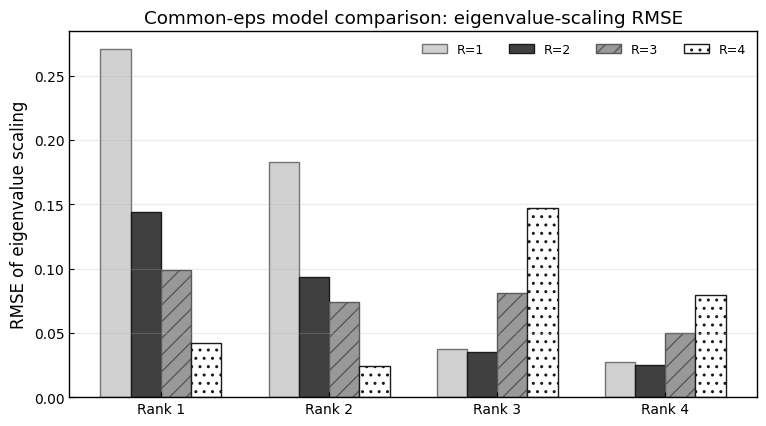

In [23]:
# ============================================================
# 3. Compact R=1/2/3/4 comparison table and figure
#    using common-eps eigenvalue-scaling RMSE (ranks 1--4)
# ============================================================

if df_rmse_ranks.empty:
    print("No rank-specific eigenvalue RMSE file found.")
else:
    check_required_columns(
        df_rmse_ranks,
        ["model", "n_factors", "rank", "eigenvalue_scaling_rmse", "eigenvalue_scaling_mae"],
        df_name="df_rmse_ranks",
    )

    factor_counts_to_plot = [1, 2, 3, 4]

    df_rmse = df_rmse_ranks[
        df_rmse_ranks["n_factors"].isin(factor_counts_to_plot)
        & df_rmse_ranks["rank"].isin([1, 2, 3, 4])
    ].copy()

    pivot_rmse = (
        df_rmse
        .pivot(index="rank", columns="n_factors", values="eigenvalue_scaling_rmse")
        .sort_index()
    )
    pivot_rmse = pivot_rmse[[R for R in factor_counts_to_plot if R in pivot_rmse.columns]]

    pivot_rmse.to_csv(
        TABLE_DIR / "table_R1_R2_R3_R4_common_eps_eigenvalue_scaling_rmse.csv"
    )
    df_rmse.to_csv(
        TABLE_DIR / "table_R1_R2_R3_R4_common_eps_eigenvalue_scaling_rmse_long.csv",
        index=False,
    )

    print("Eigenvalue scaling RMSE by model (common-eps):")
    display(pivot_rmse)

    fig, ax = plt.subplots(figsize=(7.8, 4.4))

    x = np.arange(len(pivot_rmse.index))
    n_models = len(pivot_rmse.columns)
    width = min(0.18, 0.75 / max(n_models, 1))
    offsets = (np.arange(n_models) - (n_models - 1) / 2) * width

    facecolors = {1: "0.82", 2: "0.25", 3: "0.60", 4: "1.00"}
    edgecolors = {1: "0.45", 2: "0.10", 3: "0.35", 4: "0.10"}
    hatches = {1: None, 2: None, 3: "//", 4: ".."}

    for offset, R in zip(offsets, pivot_rmse.columns):
        ax.bar(
            x + offset,
            pivot_rmse[R].values,
            width=width,
            label=f"R={R}",
            color=facecolors.get(R, "0.80"),
            edgecolor=edgecolors.get(R, "0.20"),
            linewidth=1.0,
            hatch=hatches.get(R, None),
        )

    ax.set_xticks(x)
    ax.set_xticklabels([f"Rank {r}" for r in pivot_rmse.index])
    ax.set_ylabel("RMSE of eigenvalue scaling")
    ax.set_title("Common-eps model comparison: eigenvalue-scaling RMSE")
    ax.legend(frameon=False, ncol=4)
    ax.grid(axis="y", alpha=0.25)

    fig.tight_layout()
    savefig(fig, "fig03P_common_eps_eigenvalue_scaling_rmse_bar")
    plt.show()


saved: figures\fig04_common_eps_R1_R2_R3_R4_eigenvalue_scaling_curves_rank1_to_rank4.png
saved: figures\fig04_common_eps_R1_R2_R3_R4_eigenvalue_scaling_curves_rank1_to_rank4.pdf


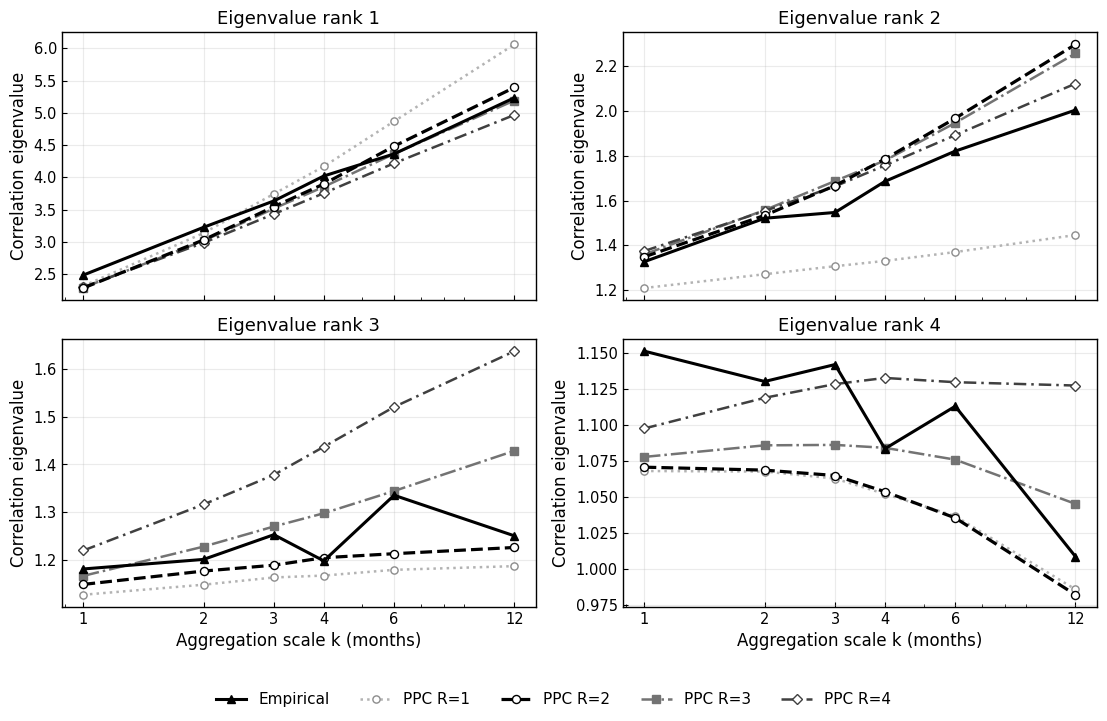

In [24]:
# ============================================================
# Figure 4: Eigenvalue scaling curves for R=1/2/3/4
# Common-eps version, grayscale manuscript figure
# ============================================================

if df_spectra.empty:
    print("No common-eps spectra file found.")
else:
    required = ["model", "n_factors", "k_month", "rank", "eig_empirical", "eig_ppc_median"]
    check_required_columns(df_spectra, required, df_name="df_spectra")

    df_plot = df_spectra.copy()
    df_plot = df_plot[df_plot["rank"].isin([1, 2, 3, 4])]
    df_plot = df_plot[df_plot["n_factors"].isin([1, 2, 3, 4])]

    df_plot.to_csv(
        TABLE_DIR / "table_R1_R2_R3_R4_common_eps_eigenvalue_scaling_full.csv",
        index=False,
    )

    fig, axes = plt.subplots(2, 2, figsize=(11.2, 7.4), sharex=True)
    axes = axes.ravel()

    empirical_style = {
        "color": "black",
        "linestyle": "-",
        "marker": "^",
        "markersize": 6.0,
        "linewidth": 2.2,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "label": "Empirical",
        "zorder": 5,
    }

    style_by_R = {
        1: {
            "color": "0.70",
            "linestyle": ":",
            "marker": "o",
            "markersize": 5.2,
            "linewidth": 1.8,
            "markerfacecolor": "white",
            "markeredgecolor": "0.55",
            "label": "PPC R=1",
            "zorder": 2,
        },
        2: {
            "color": "black",
            "linestyle": "--",
            "marker": "o",
            "markersize": 5.8,
            "linewidth": 2.3,
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "label": "PPC R=2",
            "zorder": 4,
        },
        3: {
            "color": "0.45",
            "linestyle": "-.",
            "marker": "s",
            "markersize": 5.2,
            "linewidth": 1.8,
            "markerfacecolor": "0.45",
            "markeredgecolor": "0.45",
            "label": "PPC R=3",
            "zorder": 3,
        },
        4: {
            "color": "0.25",
            "linestyle": (0, (5, 2, 1, 2)),
            "marker": "D",
            "markersize": 4.8,
            "linewidth": 1.8,
            "markerfacecolor": "white",
            "markeredgecolor": "0.25",
            "label": "PPC R=4",
            "zorder": 3,
        },
    }

    for rank, ax in zip([1, 2, 3, 4], axes):
        emp = (
            df_plot[df_plot["rank"] == rank]
            .sort_values("k_month")
            .drop_duplicates(subset=["k_month"])
        )
        if not emp.empty:
            ax.plot(emp["k_month"], emp["eig_empirical"], **empirical_style)

        for R in [1, 2, 3, 4]:
            sub = (
                df_plot[
                    (df_plot["rank"] == rank)
                    & (df_plot["n_factors"] == R)
                ]
                .sort_values("k_month")
            )
            if sub.empty:
                continue
            ax.plot(sub["k_month"], sub["eig_ppc_median"], **style_by_R[R])

        ax.set_xscale("log")
        ax.set_xticks(K_LIST)
        ax.set_xticklabels([str(k) for k in K_LIST])
        ax.set_title(f"Eigenvalue rank {rank}", fontsize=13)
        ax.set_ylabel("Correlation eigenvalue", fontsize=12)
        ax.tick_params(axis="both", labelsize=10.5)
        ax.grid(alpha=0.25)

    axes[-2].set_xlabel("Aggregation scale k (months)", fontsize=12)
    axes[-1].set_xlabel("Aggregation scale k (months)", fontsize=12)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=5,
        frameon=False,
        fontsize=11,
    )

    fig.tight_layout(rect=[0, 0.07, 1, 0.98])
    savefig(fig, "fig04_common_eps_R1_R2_R3_R4_eigenvalue_scaling_curves_rank1_to_rank4")
    plt.show()


In [25]:
# ============================================================
# 5. Off-diagonal correlation reconstruction errors for R=1/2/3/4
#    common-eps version
# ============================================================
#
# Expected inputs from the common-eps rank-sweep notebook:
#   pdata/p_paths_R1_common_eps_thin.npy
#   pdata/p_paths_R2_common_eps_thin.npy
#   pdata/p_paths_R3_common_eps_thin.npy
#   pdata/p_paths_R4_common_eps_thin.npy
# ============================================================

def clip_prob(x, eps=1.0e-10):
    return np.clip(x, eps, 1.0 - eps)


def p_paths_file_for_R(R):
    return PDATA_DIR / f"p_paths_R{R}_common_eps_thin.npy"


def make_empirical_block_arrays_from_panels(k):
    L_arr = panel_L[MODEL_SECTORS].to_numpy(dtype=int)
    N_arr = panel_N[MODEL_SECTORS].to_numpy(dtype=int)

    T0, D0 = L_arr.shape
    B = T0 // k

    L_blocks = np.empty((B, D0), dtype=int)
    N_blocks = np.empty((B, D0), dtype=int)
    start_dates = []

    for b in range(B):
        sl = slice(b * k, (b + 1) * k)
        L_blocks[b, :] = L_arr[sl, :].sum(axis=0)
        N_blocks[b, :] = N_arr[b * k, :]
        start_dates.append(panel_L.index[b * k])

    return np.asarray(start_dates), L_blocks, N_blocks


def coarse_grain_p_paths_for_corr(p_paths_monthly, k):
    p_paths_monthly = clip_prob(np.asarray(p_paths_monthly, dtype=float))

    if k == 1:
        return p_paths_monthly

    M, T0, D0 = p_paths_monthly.shape
    B = T0 // k

    out = np.empty((M, B, D0), dtype=float)
    for b in range(B):
        block = p_paths_monthly[:, b * k:(b + 1) * k, :]
        out[:, b, :] = 1.0 - np.prod(1.0 - block, axis=1)

    return clip_prob(out)


def empirical_rate_matrix_for_k(k):
    _, L_k, N_k = make_empirical_block_arrays_from_panels(k)
    return L_k / (N_k * k), L_k, N_k


def safe_corrcoef_rate_matrix(rate_matrix):
    C = np.corrcoef(rate_matrix, rowvar=False)
    C = 0.5 * (C + C.T)
    return C


def offdiag_values(C):
    C = np.asarray(C, dtype=float)
    mask = ~np.eye(C.shape[0], dtype=bool)
    return C[mask]


def ppc_corr_median_for_R_k(R, k, n_ppc=1000):
    path = p_paths_file_for_R(R)
    if not path.exists():
        print(f"WARNING: missing p_paths file for R={R}: {path}")
        return None, None, None

    p_paths_monthly = np.load(path)
    p_paths_monthly = clip_prob(p_paths_monthly)

    r_emp_k, L_k, N_k = empirical_rate_matrix_for_k(k)
    C_emp = safe_corrcoef_rate_matrix(r_emp_k)

    p_k = coarse_grain_p_paths_for_corr(p_paths_monthly, k)

    M = p_k.shape[0]
    M_use = min(n_ppc, M)
    idx = np.linspace(0, M - 1, M_use).astype(int)

    rng_local = np.random.default_rng(SEED + 1000 * R + 100 * k)

    C_draws = np.empty((M_use, len(MODEL_SECTORS), len(MODEL_SECTORS)), dtype=float)

    for m, j in enumerate(idx):
        p_s = clip_prob(p_k[j])
        L_rep_s = rng_local.binomial(n=N_k.astype(int), p=p_s)
        r_rep_s = L_rep_s / (N_k * k)
        C_draws[m] = safe_corrcoef_rate_matrix(r_rep_s)

    C_ppc_med = np.nanmedian(C_draws, axis=0)
    C_ppc_med = 0.5 * (C_ppc_med + C_ppc_med.T)
    np.fill_diagonal(C_ppc_med, 1.0)

    return C_emp, C_ppc_med, C_draws


error_rows = []

for R in FACTOR_COUNTS:
    for k in [1, 12]:
        C_emp, C_ppc_med, _ = ppc_corr_median_for_R_k(R=R, k=k, n_ppc=1000)
        if C_emp is None:
            continue

        emp_off = offdiag_values(C_emp)
        ppc_off = offdiag_values(C_ppc_med)
        diff_off = ppc_off - emp_off

        error_rows.append({
            "n_factors": R,
            "k_month": k,
            "offdiag_corr_rmse": float(np.sqrt(np.nanmean(diff_off**2))),
            "offdiag_corr_mae": float(np.nanmean(np.abs(diff_off))),
        })

df_offdiag_errors = pd.DataFrame(error_rows).sort_values(["n_factors", "k_month"])
out_long = TABLE_DIR / "table_R1_R2_R3_R4_common_eps_offdiag_corr_errors.csv"
df_offdiag_errors.to_csv(out_long, index=False)
print("saved:", out_long)
display(df_offdiag_errors)


saved: tables\table_R1_R2_R3_R4_common_eps_offdiag_corr_errors.csv


,n_factors,k_month,offdiag_corr_rmse,offdiag_corr_mae
0,1,1,0.066520,0.046594
1,1,12,0.173528,0.144729
2,2,1,0.059595,0.045853
3,2,12,0.149436,0.119866
4,3,1,0.058111,0.043876
5,3,12,0.148227,0.117563
6,4,1,0.055781,0.038472
7,4,12,0.139496,0.103751


In [26]:
# ============================================================
# 6. Off-diagonal correlation-scaling RMSE over all horizons
# common-eps version
# ============================================================

K_LIST = [1, 2, 3, 4, 6, 12]

corr_scaling_rows = []

for R in FACTOR_COUNTS:
    sq_errors_all = []

    for k in K_LIST:
        C_emp, C_ppc_med, _ = ppc_corr_median_for_R_k(R=R, k=k, n_ppc=1000)
        if C_emp is None:
            continue

        emp_off = offdiag_values(C_emp)
        ppc_off = offdiag_values(C_ppc_med)
        diff_off = ppc_off - emp_off
        sq_errors_all.extend((diff_off**2).tolist())

    corr_scaling_rows.append({
        "n_factors": R,
        "offdiag_corr_scaling_rmse": float(np.sqrt(np.nanmean(sq_errors_all))),
        "n_error_terms": int(len(sq_errors_all)),
    })

df_corr_scaling_rmse = pd.DataFrame(corr_scaling_rows).sort_values("n_factors").reset_index(drop=True)

out_corr_scaling = TABLE_DIR / "table_R1_R2_R3_R4_common_eps_offdiag_corr_scaling_rmse.csv"
df_corr_scaling_rmse.to_csv(out_corr_scaling, index=False)
print("saved:", out_corr_scaling)
display(df_corr_scaling_rmse)


saved: tables\table_R1_R2_R3_R4_common_eps_offdiag_corr_scaling_rmse.csv


,n_factors,offdiag_corr_scaling_rmse,n_error_terms
0,1,0.114969,936
1,2,0.098192,936
2,3,0.098261,936
3,4,0.094516,936


In [27]:
# ============================================================
# 7. Combine eigenvalue-scaling RMSE and off-diagonal correlation-scaling RMSE
# into one factor-selection table (common-eps version)
# ============================================================

if "pivot_rmse" not in globals():
    raise NameError("pivot_rmse is not defined. Run the eigenvalue RMSE comparison cell first.")

if "df_corr_scaling_rmse" not in globals():
    raise NameError("df_corr_scaling_rmse is not defined. Run the off-diagonal correlation-scaling RMSE cell first.")

factor_counts_to_table = [1, 2, 3, 4]
rows = []

for rank in [1, 2, 3, 4]:
    row = {"diagnostic": f"Rank {rank} eigenvalue-scaling RMSE"}
    for R in factor_counts_to_table:
        row[f"R={R}"] = float(pivot_rmse.loc[rank, R]) if (R in pivot_rmse.columns and rank in pivot_rmse.index) else np.nan
    rows.append(row)

corr_row = {"diagnostic": "Off-diagonal correlation-scaling RMSE"}
for R in factor_counts_to_table:
    tmp = df_corr_scaling_rmse[df_corr_scaling_rmse["n_factors"] == R]
    corr_row[f"R={R}"] = float(tmp["offdiag_corr_scaling_rmse"].iloc[0]) if len(tmp) > 0 else np.nan
rows.append(corr_row)

avg_row = {"diagnostic": "Average eigenvalue-scaling RMSE (ranks 1--4)"}
for R in factor_counts_to_table:
    avg_row[f"R={R}"] = float(pivot_rmse.loc[[1, 2, 3, 4], R].mean()) if R in pivot_rmse.columns else np.nan
rows.append(avg_row)

if not df_rmse_avg_all_ranks.empty:
    avg_all_row = {"diagnostic": "Average eigenvalue-scaling RMSE (all ranks)"}
    for R in factor_counts_to_table:
        tmp = df_rmse_avg_all_ranks[df_rmse_avg_all_ranks["n_factors"] == R]
        avg_all_row[f"R={R}"] = float(tmp["average_rmse_all_ranks"].iloc[0]) if len(tmp) > 0 else np.nan
    rows.append(avg_all_row)

df_factor_selection_extended = pd.DataFrame(rows)
out_extended = TABLE_DIR / "table_factor_selection_diagnostics_extended_common_eps.csv"
df_factor_selection_extended.to_csv(out_extended, index=False)
print("saved:", out_extended)
display(df_factor_selection_extended)


saved: tables\table_factor_selection_diagnostics_extended_common_eps.csv


,diagnostic,R=1,R=2,R=3,R=4
0,Rank 1 eigenvalue-scaling RMSE,0.270891,0.143814,0.098708,0.042012
1,Rank 2 eigenvalue-scaling RMSE,0.183060,0.093697,0.074203,0.023904
2,Rank 3 eigenvalue-scaling RMSE,0.037494,0.035484,0.081245,0.146792
3,Rank 4 eigenvalue-scaling RMSE,0.027345,0.025230,0.049804,0.079335
4,Off-diagonal correlation-scaling RMSE,0.114969,0.098192,0.098261,0.094516
5,Average eigenvalue-scaling RMSE (ranks 1--4),0.129697,0.074556,0.075990,0.073011
6,Average eigenvalue-scaling RMSE (all ranks),0.079014,0.064684,0.066386,0.064050


In [28]:
# ============================================================
# 8. Selection statement table (common-eps results)
# ============================================================

selection_rows = [
    {
        "model": "R=2",
        "role": "Main model",
        "interpretation": "Market-wide factor plus sector-rotation factor",
        "selection_reason": "Large improvement over R=1, interpretable two-factor structure, better posterior stability than higher-rank alternatives, and a parsimonious representation of the leading coarse-grained spectral dynamics.",
    },
    {
        "model": "R=3",
        "role": "Diagnostic extension",
        "interpretation": "Adds a third empirical sector mode",
        "selection_reason": "Does not materially improve the average rank-1--4 eigenvalue-scaling RMSE relative to R=2 and has weaker posterior diagnostics, so the additional persistent factor is not adopted as part of the baseline.",
    },
    {
        "model": "R=4",
        "role": "Diagnostic extension",
        "interpretation": "Adds third and fourth empirical sector modes",
        "selection_reason": "May give a marginally smaller average rank-1--4 eigenvalue-scaling RMSE, but the gain over R=2 is negligible and comes with weaker posterior diagnostics and over-amplification of non-leading eigenvalue behavior, especially the third rank.",
    },
]


df_selection_statement = pd.DataFrame(selection_rows)
df_selection_statement.to_csv(TABLE_DIR / "table_factor_selection_statement_common_eps.csv", index=False)
display(df_selection_statement)


,model,role,interpretation,selection_reason
0,R=2,Main model,Market-wide factor plus sector-rotation factor,"Large improvement over R=1, interpretable two-..."
1,R=3,Diagnostic extension,Adds a third empirical sector mode,Does not materially improve the average rank-1...
2,R=4,Diagnostic extension,Adds third and fourth empirical sector modes,May give a marginally smaller average rank-1--...
